In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re

In [2]:
# ========= 1. 實驗設定 (Configuration) =========

base_dir = r"C:\experiment\2D"

experiments = [
    {"file": os.path.join(base_dir, "t0145", "t0145.csv")  , "group_val": 10,   "group": "10cm"},
    {"file": os.path.join(base_dir, "t0148", "t0148.csv")  , "group_val": 12.5, "group": "12.5cm"},
    {"file": os.path.join(base_dir, "t0137", "t0137.csv")  , "group_val": 30,   "group": "15cm"},
    {"file": os.path.join(base_dir, "t0149", "t0149.csv")  , "group_val": 17.5, "group": "17.5cm"},
    # {"file": os.path.join(base_dir, "t0141", "t0141.csv"), "group_val": 40, "group": "40cm"}
]

# 圖表 X 軸 (Normal Stress) 顯示範圍
xlim_min = 0
xlim_max = 10


In [3]:
# ========= 2. 資料處理 (Data Processing) =========

def extract_sigma(run_name):
    """ 從 run1_32MPa 這樣的字串中提取 32 作為數值 """
    match = re.search(r'_(\d+)MPa', str(run_name))
    if match:
        return float(match.group(1))
    return np.nan



def process_data(target_metric):
    """ 讀取 CSV 並計算各組在每個 sigma 下的 median 與 IQR """
    processed_data = []
    for exp in experiments:
        if not os.path.exists(exp['file']):
            print(f"找不到檔案: {exp['file']}")
            continue
            
        df = pd.read_csv(exp['file'])
        
        if 'skipped' in df.columns:
            df = df[df['skipped'] != 'YES'].copy()
            
        if target_metric == 'k' and 'k' in df.columns:
            df = df[pd.to_numeric(df['k'], errors='coerce') >= 0]

        
        if target_metric not in df.columns:
            continue
            
        # 提取 sigma
        df['sigma'] = df['Run'].apply(extract_sigma)
        df = df.dropna(subset=['sigma', target_metric])
        
        # 計算各個 sigma 的統計量
        stats = df.groupby('sigma')[target_metric].agg(
            median='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75)
        ).reset_index()
        
        processed_data.append({
            'group': exp['group'],
            'group_val': exp['group_val'],
            'stats': stats
        })
    return processed_data


In [4]:
# ========= 3. 繪製圖表函數 (Plotting Function) =========

def plot_metric(target_metric, title, ylabel):
    data_to_plot = process_data(target_metric)
    if not data_to_plot:
        print(f"找不到 {target_metric} 的資料")
        return

    # 離散 colormap：從 Set2 原始 8 色中按序取前 n 個
    group_vals = [item['group_val'] for item in data_to_plot]
    n = len(group_vals)
    cmap_full = plt.get_cmap('Set2')  # 原始 8 色
    colors = [cmap_full(i / 8) for i in range(n)]  # 按序取前 n 個
    val_to_idx = {v: i for i, v in enumerate(group_vals)}

    # 用於 colorbar 的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))

    all_sigmas = []
    texts_to_draw = []
    for item in data_to_plot:
        stats = item['stats']
        sigmas = stats['sigma'].values
        medians = stats['median'].values
        yerr_lower = medians - stats['q1'].values
        yerr_upper = stats['q3'].values - medians
        color = colors[val_to_idx[item['group_val']]]

        all_sigmas.extend(sigmas)

        ax.errorbar(
            sigmas, medians,
            yerr=[yerr_lower, yerr_upper],
            fmt="s", color=color,
            markersize=10, capsize=5,
            markeredgewidth=2,
            elinewidth=1.5, alpha=0.8, zorder=3
        )

        # Add trend line
        if target_metric == 'delta_tau' and len(sigmas) > 2:
            coefs = np.polyfit(sigmas, medians, 2)
            x_line = np.linspace(sigmas.min(), sigmas.max(), 50)
            y_line = np.polyval(coefs, x_line)
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
        elif len(sigmas) > 1:
            slope, intercept = np.polyfit(sigmas, medians, 1)
            x_line = np.array([sigmas.min(), sigmas.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                'x': x_line[-1] + 0.5,
                'y': y_line[-1],
                'text': f' m={slope:.3g}',
                'color': color
            })

    ax.set_xlabel(r'Normal Stress $\sigma$ [MPa]', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.6)
    ax.set_xlim(xlim_min, xlim_max)

    if all_sigmas:
        ax.set_xticks(np.unique(all_sigmas))

    # 離散 colorbar
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)))
    cbar.set_label('Seismogenic Zone Size [cm]', fontsize=11)
    cbar.ax.set_yticklabels([item['group'] for item in data_to_plot])
    plt.tight_layout()
    plt.show()


In [5]:
# ========= 4. 以群組為 X 軸的繪圖函數 (Group X-Axis Plotting Function) =========

def plot_metric_by_group(target_metric, title, ylabel):
    """以實驗群組為 X 軸（順序與 experiments 設定相同），不同 sigma 為系列繪圖。"""
    group_order = [exp["group"] for exp in experiments]
    group_xval  = {g: i for i, g in enumerate(group_order)}

    data_to_plot = process_data(target_metric)
    if not data_to_plot:
        print(f"找不到 {target_metric} 欄位")
        return

    # 收集所有出現的 sigma 值
    all_sigmas_set = set()
    for item in data_to_plot:
        all_sigmas_set.update(item["stats"]["sigma"].values)
    unique_sigmas = sorted(all_sigmas_set)

    # 離散 colormap：從 Set2 原始 8 色中按序取前 n 個
    n = len(unique_sigmas)
    cmap_full = plt.get_cmap('Set2')  # 原始 8 色
    colors = [cmap_full(i / 8) for i in range(n)]  # 按序取前 n 個
    sigma_to_idx = {s: i for i, s in enumerate(unique_sigmas)}

    # 用於 colorbar 的 ScalarMappable
    from matplotlib.colors import ListedColormap, BoundaryNorm
    cmap_cb = ListedColormap(colors)
    bounds = [i - 0.5 for i in range(n)] + [n - 0.5]
    norm_cb = BoundaryNorm(bounds, cmap_cb.N)
    sm = plt.cm.ScalarMappable(cmap=cmap_cb, norm=norm_cb)
    sm.set_array([])

    fig, ax = plt.subplots(figsize=(8, 5))
    texts_to_draw = []

    for sigma in unique_sigmas:
        x_vals, y_vals, yerr_lo, yerr_hi = [], [], [], []

        for item in data_to_plot:
            group = item["group"]
            if group not in group_xval:
                continue
            stats = item["stats"]
            row = stats[stats["sigma"] == sigma]
            if row.empty:
                continue
            x_vals.append(group_xval[group])
            med = row["median"].values[0]
            q1  = row["q1"].values[0]
            q3  = row["q3"].values[0]
            y_vals.append(med)
            yerr_lo.append(med - q1)
            yerr_hi.append(q3 - med)

        if not x_vals:
            continue

        x_arr = np.array(x_vals)
        y_arr = np.array(y_vals)
        color = colors[sigma_to_idx[sigma]]

        ax.errorbar(
            x_arr, y_arr,
            yerr=[np.array(yerr_lo), np.array(yerr_hi)],
            fmt="s", color=color,
            markersize=10, capsize=5,
            markeredgewidth=2,
            elinewidth=1.5, alpha=0.8, zorder=3
        )

        # 趨勢線
        if target_metric == 'delta_tau' and len(x_arr) > 2:
            coefs = np.polyfit(x_arr, y_arr, 2)
            x_line = np.linspace(x_arr.min(), x_arr.max(), 50)
            y_line = np.polyval(coefs, x_line)
            ax.plot(x_line, y_line, color=color, linestyle="--", linewidth=1.5, alpha=0.6, zorder=2)
        elif len(x_arr) > 1:
            slope, intercept = np.polyfit(x_arr, y_arr, 1)
            x_line = np.array([x_arr.min(), x_arr.max()])
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle="--", linewidth=1.5, alpha=0.6, zorder=2)
            texts_to_draw.append({
                "x": x_line[-1] + 0.1,
                "y": y_line[-1],
                "text": f" m={slope:.3g}",
                "color": color
            })

    ax.set_xlabel("Seismogenic Zone Radius", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xlim(-0.5, len(group_order) - 0.5)
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order)
    ax.grid(True, alpha=0.6)

    # 離散 colorbar
    cbar = fig.colorbar(sm, ax=ax, ticks=list(range(n)))
    cbar.set_label(r'Normal Stress $\sigma$ [MPa]', fontsize=11)
    cbar.ax.set_yticklabels([f'{s:.0f} MPa' for s in unique_sigmas])
    plt.tight_layout()
    plt.show()


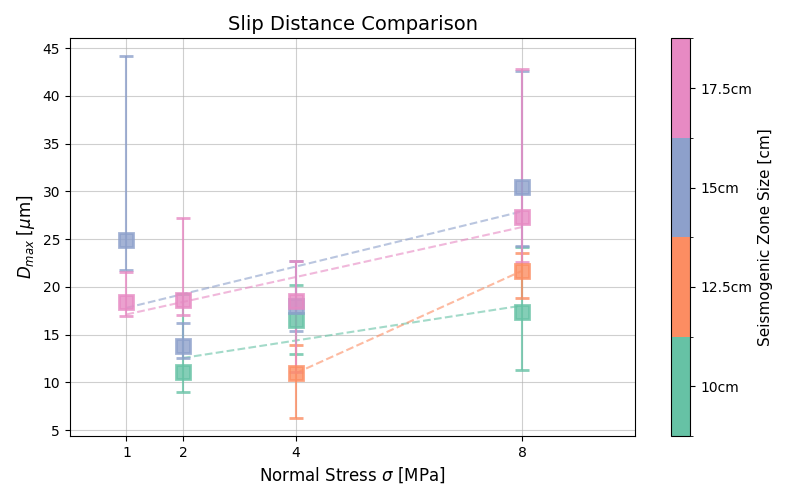

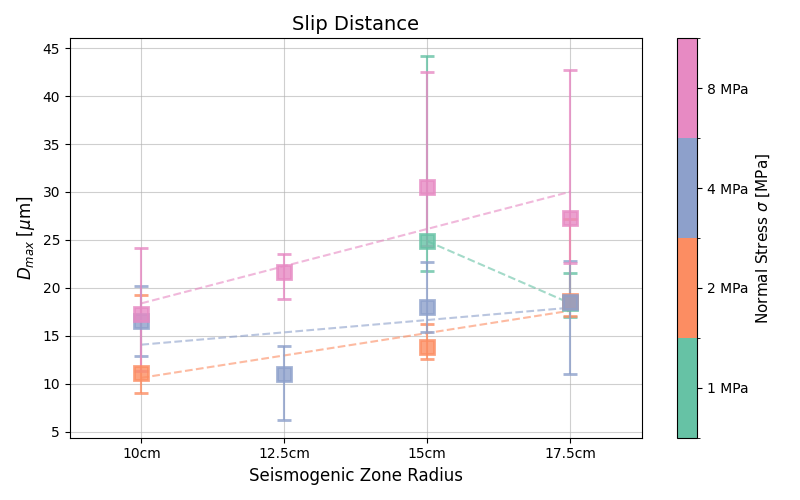

In [6]:
# === 繪製 D_max 圖 ===
plot_metric('D_max', 'Slip Distance Comparison', r'$D_{max}$ [$\mu$m]')
# === 以群組為 X 軸：D_max 圖 ===
plot_metric_by_group('D_max', 'Slip Distance', r'$D_{max}$ [$\mu$m]')

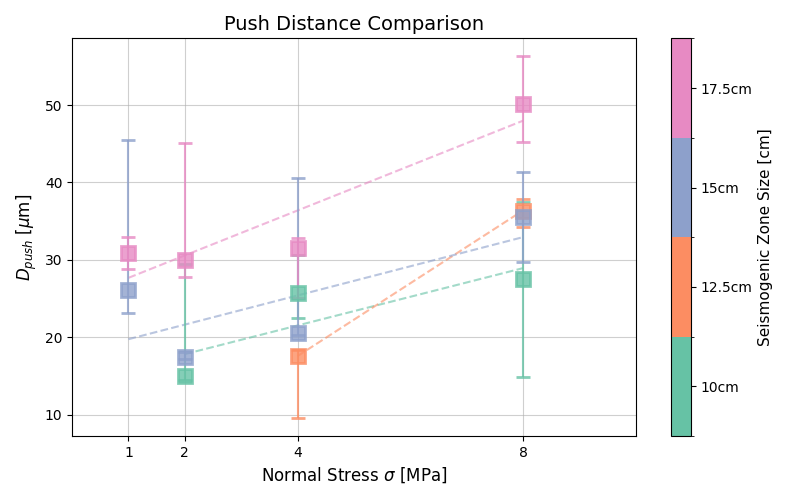

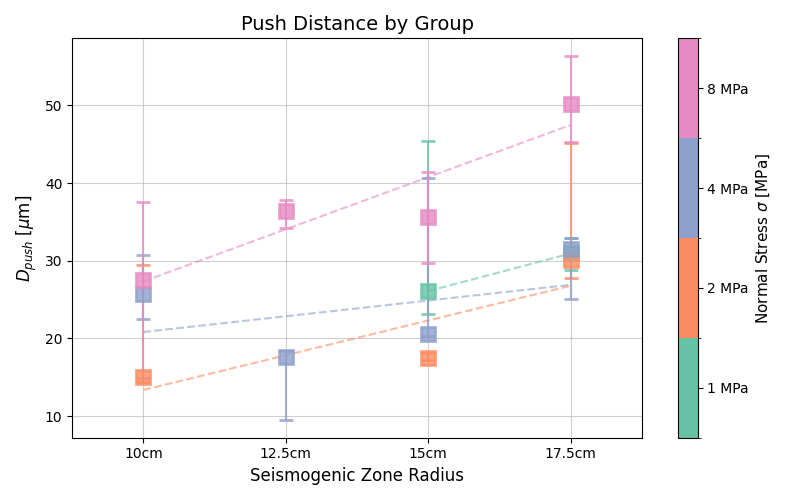

In [7]:
# === 繪製 D_Push 圖 ===
plot_metric('D_Push', 'Push Distance Comparison', r'$D_{push}$ [$\mu$m]')
# === 以群組為 X 軸：D_Push 圖 ===
plot_metric_by_group('D_Push', 'Push Distance by Group', r'$D_{push}$ [$\mu$m]')

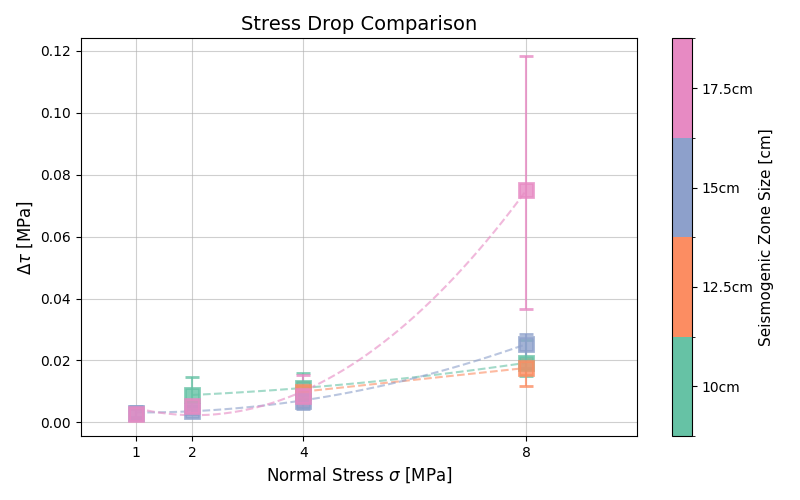

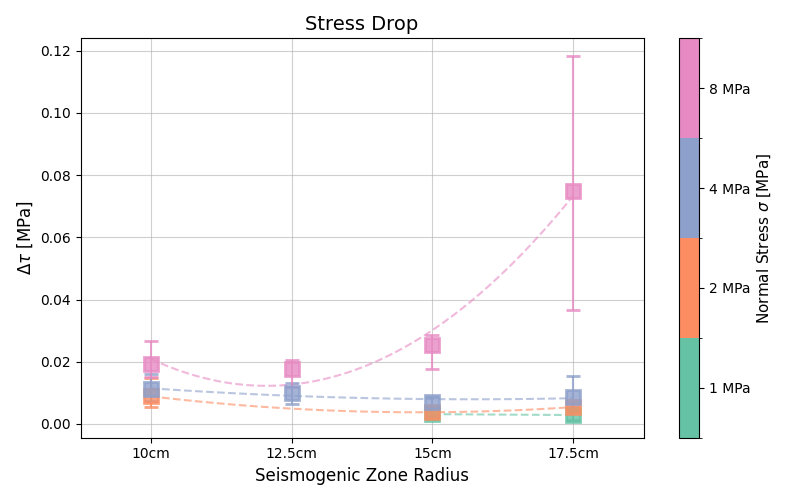

In [8]:
# === 繪製 Delta Tau 圖 ===
plot_metric('delta_tau', 'Stress Drop Comparison', r'$\Delta\tau$ [MPa]')
# === 以群組為 X 軸：Stress Drop 圖 ===
plot_metric_by_group('delta_tau', 'Stress Drop', r'$\Delta\tau$ [MPa]')


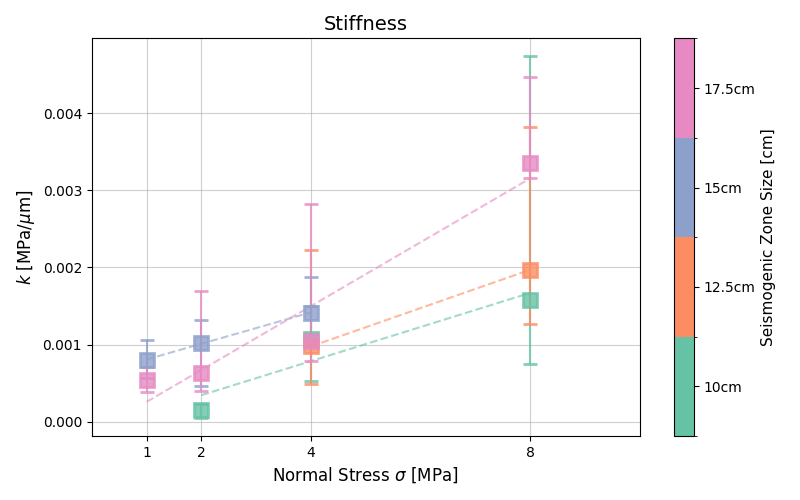

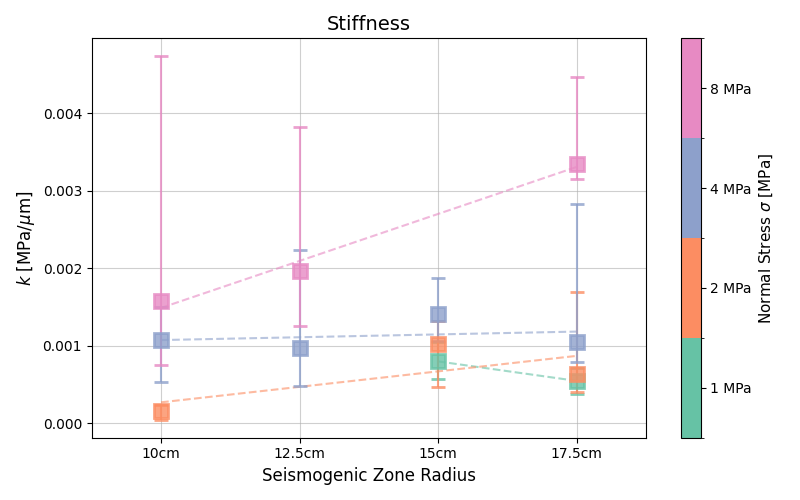

In [9]:
# === 繪製 Stiffness k 圖 ===
plot_metric('k', 'Stiffness', r'$k$ [MPa/$\mu$m]')
# === 以群組為 X 軸：Stiffness k 圖 ===
plot_metric_by_group('k', 'Stiffness', r'$k$ [MPa/$\mu$m]')


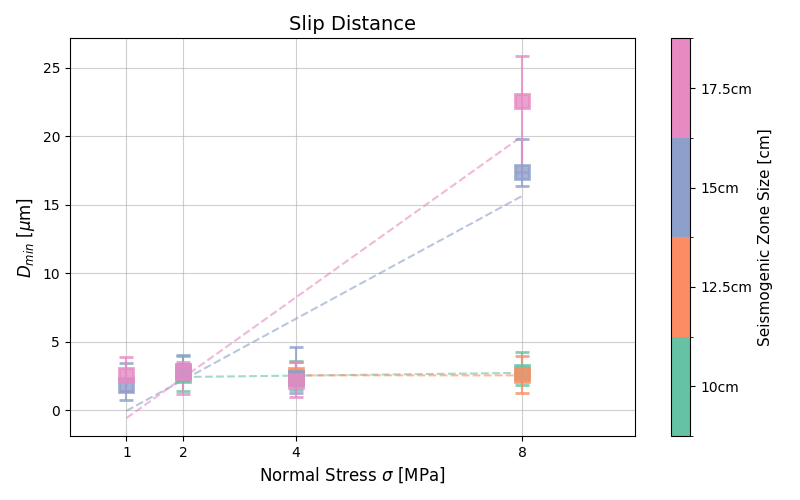

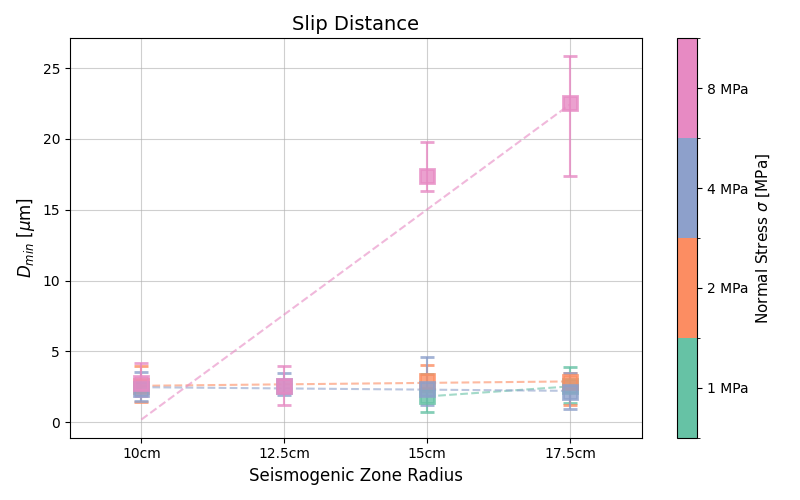

In [10]:
# ========= 畫 D_min (使用 LVDT 位移) 的圖表 =========
# 1. 畫以 Normal Stress (sigma) 為 X 軸的圖
plot_metric('delta_lvdt', 'Slip Distance', r'$D_{min}$ [$\mu$m]')
# 2. 畫以實驗群組為 X 軸的圖
plot_metric_by_group('delta_lvdt', 'Slip Distance', r'$D_{min}$ [$\mu$m]')